<a href="https://colab.research.google.com/github/Garad9901/YASH-GARAD/blob/main/AI_Cyber_Threat_Detection_%26_Response_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install all required packages
!pip install stable-baselines3 gymnasium scikit-learn matplotlib seaborn pandas numpy tensorflow streamlit pyngrok -q

print("✅ All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.7 MB/s eta 0:00:00
✅ All packages installed.


In [2]:
# Cell 2: Download NSL-KDD Dataset
import pandas as pd
import numpy as np

# Download links
TRAIN_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
TEST_URL  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"

# NSL-KDD column names (41 features + label + difficulty)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train_df = pd.read_csv(TRAIN_URL, header=None, names=columns)
test_df  = pd.read_csv(TEST_URL,  header=None, names=columns)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print("\nLabel distribution (Train):")
print(train_df['label'].value_counts().head(10))

Train shape: (125973, 43)
Test shape:  (22544, 43)

Label distribution (Train):
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


In [4]:
# Cell 3: Preprocessing & Feature Engineering
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import os

os.makedirs('data', exist_ok=True)
os.makedirs('model', exist_ok=True)

# Multi-class: group attack families
ATTACK_MAP = {
    'normal': 'Normal',
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
}

def preprocess(df, fit_encoders=None, fit_scaler=None):
    df = df.copy()
    df.drop(columns=['difficulty'], inplace=True)

    # Map labels: 'normal' → 0, everything else → 1 (binary)
    df['binary_label'] = (df['label'] != 'normal').astype(int)

    # Multi-class: group attack families
    df['attack_class'] = df['label'].map(ATTACK_MAP).fillna('Other')

    # Encode categoricals
    cat_cols = ['protocol_type', 'service', 'flag']
    encoders = fit_encoders if fit_encoders else {}
    for col in cat_cols:
        if col not in encoders:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le
        else:
            # Handle potential unseen categoricals in service/flag by mapping to known class
            df[col] = df[col].apply(lambda x: x if x in encoders[col].classes_ else encoders[col].classes_[0])
            df[col] = encoders[col].transform(df[col])

    feature_cols = [c for c in df.columns if c not in ['label', 'binary_label', 'attack_class']]
    X = df[feature_cols].values.astype(np.float32)

    scaler = fit_scaler if fit_scaler else StandardScaler()
    if fit_scaler is None:
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)

    return X, df['binary_label'].values, df['attack_class'].values, encoders, scaler, feature_cols

X_train, y_bin_train, y_cls_train, encoders, scaler, feature_cols = preprocess(train_df)
X_test,  y_bin_test,  y_cls_test,  _,        _,      _            = preprocess(test_df, encoders, scaler)

# Encode attack classes - ensuring 'Other' is accounted for
cls_encoder = LabelEncoder()
all_possible_classes = list(set(list(ATTACK_MAP.values()) + ['Other']))
cls_encoder.fit(all_possible_classes)

y_cls_train_enc = cls_encoder.transform(y_cls_train)
y_cls_test_enc  = cls_encoder.transform(y_cls_test)

print(f"Features: {len(feature_cols)}")
print(f"Classes: {cls_encoder.classes_}")
np.save('data/X_train.npy', X_train)
np.save('data/X_test.npy',  X_test)
np.save('data/y_bin_train.npy', y_bin_train)
np.save('data/y_bin_test.npy',  y_bin_test)
np.save('data/y_cls_train.npy', y_cls_train_enc)
np.save('data/y_cls_test.npy',  y_cls_test_enc)
print("✅ Preprocessing complete. Data saved.")

Features: 41
Classes: ['DoS' 'Normal' 'Other' 'Probe' 'R2L' 'U2R']
✅ Preprocessing complete. Data saved.


Training Autoencoder on 67343 normal samples...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,617 (41.47 KB)

 Trainable params: 10,617 (41.47 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5697 - val_loss: 0.2156
Epoch 2/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3225 - val_loss: 0.1225
Epoch 3/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2631 - val_loss: 0.1031
Epoch 4/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2446 - val_loss: 0.1947
Epoch 5/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2444 - val_loss: 0.1148
Epoch 6/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2059 - val_loss: 0.0765
Epoch 7/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1738 - val_loss: 0.0707
Epoch 8/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1450 - val_loss: 0.0859
Epoch 9/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1575 - val_loss: 0.0626
Epoch 10/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1502 - val_loss: 0.0607
Epoch 11/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1132 - val_loss: 0.0681
Epoch 12/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

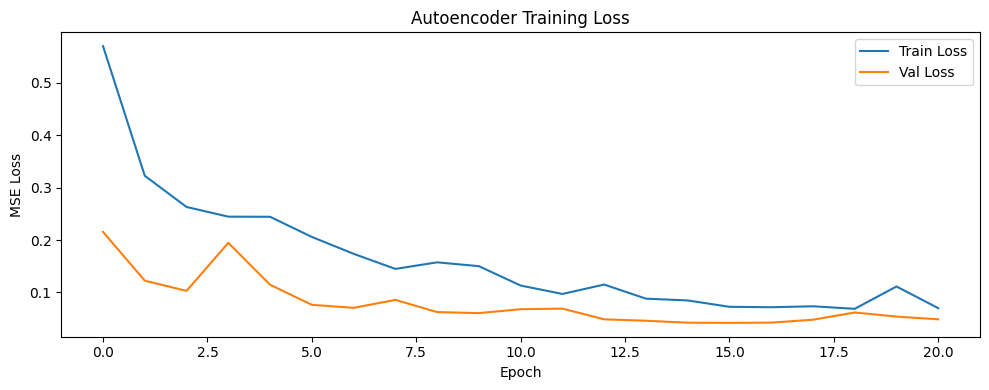

✅ Autoencoder trained & saved.


In [5]:
# Cell 4: Autoencoder for Anomaly Detection
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# Train only on NORMAL traffic
X_normal = X_train[y_bin_train == 0]
print(f"Training Autoencoder on {X_normal.shape[0]} normal samples...")

input_dim = X_train.shape[1]

# Build Autoencoder
inputs = tf.keras.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(inputs)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)
encoded = layers.Dense(16, activation='relu')(encoded)

decoded = layers.Dense(32, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

history = autoencoder.fit(
    X_normal, X_normal,
    epochs=30, batch_size=256,
    validation_split=0.1, verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

autoencoder.save('model/autoencoder.h5')

# Plot training
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.tight_layout(); plt.show()
print("✅ Autoencoder trained & saved.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,830 (210.27 KB)

 Trainable params: 53,062 (207.27 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9579 - loss: 0.1377 - val_accuracy: 0.9897 - val_loss: 0.0475
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9862 - loss: 0.0407 - val_accuracy: 0.9929 - val_loss: 0.0260
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9886 - loss: 0.0335 - val_accuracy: 0.9930 - val_loss: 0.0232
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9898 - loss: 0.0295 - val_accuracy: 0.9941 - val_loss: 0.0196
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9903 - loss: 0.0277 - val_accuracy: 0.9938 - val_loss: 0.0194
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9911 - loss: 0.0260 - val_accuracy: 0.9950 - val_loss: 0.0169
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9920 - loss: 0.0237 - val_accuracy: 0.9949 - val_loss: 0.0165
Epoch 8/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9922 - loss: 0.0226 - val_acc

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 Classification Report:
              precision    recall  f1-score   support

         DoS       0.94      0.94      0.94      6034
      Normal       0.65      0.98      0.78      9711
       Other       0.00      0.00      0.00      3457
       Probe       0.42      0.74      0.54      1106
         R2L       0.54      0.00      0.01      2199
         U2R       0.50      0.38      0.43        37

    accuracy                           0.71     22544
   macro avg       0.51      0.51      0.45     22544
weighted avg       0.61      0.71      0.62     22544



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


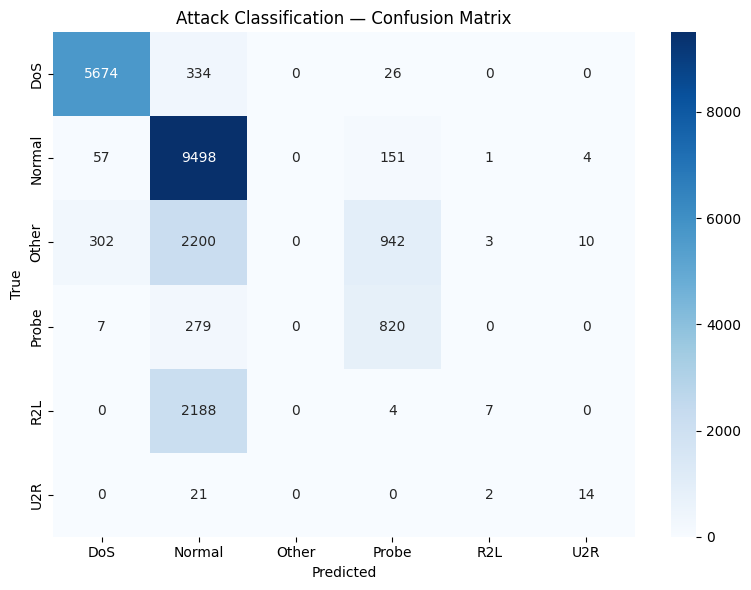

In [6]:
# Cell 5: Multi-class Attack Classifier
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

num_classes = len(cls_encoder.classes_)
y_cat_train = to_categorical(y_cls_train_enc, num_classes)
y_cat_test  = to_categorical(y_cls_test_enc,  num_classes)

# Build DNN Classifier
def build_classifier(input_dim, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

classifier = build_classifier(input_dim, num_classes)
classifier.summary()

history_cls = classifier.fit(
    X_train, y_cat_train,
    epochs=30, batch_size=512,
    validation_split=0.1, verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

classifier.save('model/classifier.h5')

# Evaluate
y_pred = np.argmax(classifier.predict(X_test), axis=1)
print("\n📊 Classification Report:")
print(classification_report(y_cls_test_enc, y_pred, target_names=cls_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_cls_test_enc, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cls_encoder.classes_, yticklabels=cls_encoder.classes_)
plt.title('Attack Classification — Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()


In [7]:
# Cell 6: Reinforcement Learning Response Engine
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# Define action space: 5 mitigation responses
ACTIONS = {
    0: "✅ Allow Traffic",
    1: "⚠️  Log & Monitor",
    2: "🔒 Rate Limit",
    3: "🚫 Block IP",
    4: "🚨 Isolate & Alert SOC"
}

class CyberDefenseEnv(gym.Env):
    """Custom RL environment for threat response."""
    metadata = {'render_modes': ['human']}

    def __init__(self, X, y_binary, y_class):
        super().__init__()
        self.X = X
        self.y_binary = y_binary
        self.y_class = y_class
        self.n_samples = len(X)
        self.current_idx = 0

        self.observation_space = spaces.Box(
            low=-10, high=10, shape=(X.shape[1],), dtype=np.float32)
        self.action_space = spaces.Discrete(5)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_idx = np.random.randint(0, self.n_samples)
        obs = self.X[self.current_idx].astype(np.float32)
        return obs, {}

    def step(self, action):
        is_attack = self.y_binary[self.current_idx]
        attack_class = self.y_class[self.current_idx]

        # Reward shaping
        if is_attack == 0:  # Normal traffic
            reward = 1.0 if action == 0 else -0.5  # Allow is correct
        else:  # Attack traffic
            severity = {0: 1, 1: 1, 2: 2, 3: 3, 4: 3}.get(attack_class, 2)
            if action == 0:   reward = -2.0 * severity  # False negative: very bad
            elif action == 1: reward = 0.3
            elif action == 2: reward = 0.6
            elif action == 3: reward = 0.8 * severity
            elif action == 4: reward = 1.0 * severity   # Best response to serious attacks

        self.current_idx = np.random.randint(0, self.n_samples)
        obs = self.X[self.current_idx].astype(np.float32)
        return obs, reward, False, False, {}

    def render(self):
        pass

# Initialize environment
env = CyberDefenseEnv(X_train, y_bin_train, y_cls_train_enc)
check_env(env, warn=True)

# Train PPO Agent
print("🤖 Training RL Agent (PPO)...")
rl_agent = PPO("MlpPolicy", env, verbose=1, n_steps=2048, batch_size=64,
               learning_rate=3e-4, ent_coef=0.01)
rl_agent.learn(total_timesteps=100_000)
rl_agent.save("model/rl_ppo_agent")
print("✅ RL Agent trained & saved.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


🤖 Training RL Agent (PPO)...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 1217 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| time/                   |              |
|    fps                  | 804          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0125693455 |
|    clip_fraction        | 0.159        |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.6         |
|    explained_variance   | -0.0166      |
|    learning_rate        | 0.0003       |
|    loss                 | 8.17         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0285      |
|    value_loss           | 15.8         |
------------------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 769          |
|    iterations           | 3            |
|    time_elapsed         | 7            |
|    total_

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
📌 Anomaly Threshold: 4.073233
🎯 ROC-AUC Score: 0.9467
✅ Detected 86 anomalies out of 22544 samples


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


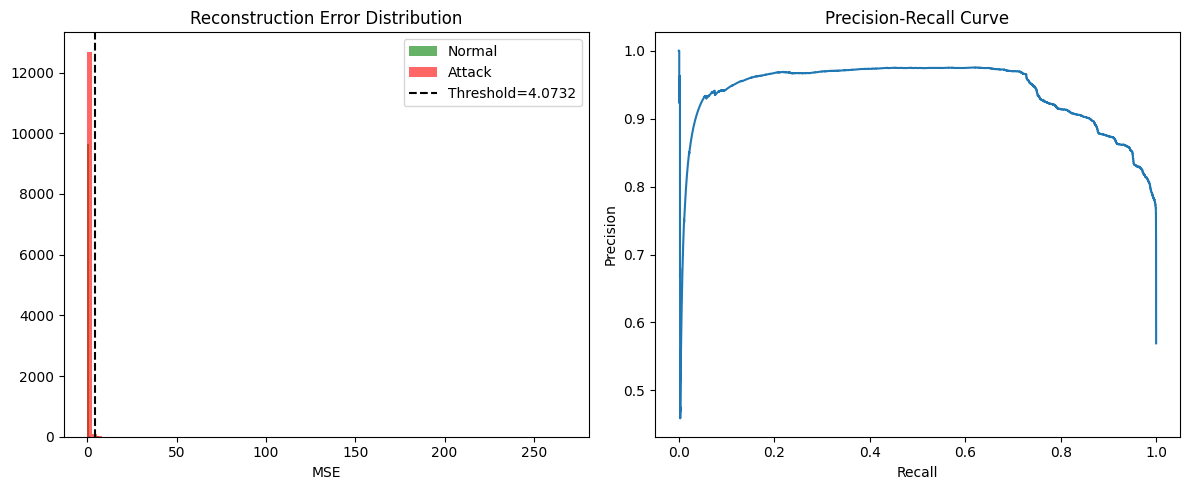

In [9]:
# Cell 7: Set threshold & run full pipeline inference
from sklearn.metrics import roc_auc_score, precision_recall_curve

# Compute reconstruction errors
# Fix: Added custom_objects to resolve the 'mse' deserialization error
try:
    ae = tf.keras.models.load_model('model/autoencoder.h5', custom_objects={'mse': tf.keras.losses.MeanSquaredError()})
except Exception as e:
    print(f"Fallback: Attempting to load without compilation if error persists: {e}")
    ae = tf.keras.models.load_model('model/autoencoder.h5', compile=False)

recon_normal = ae.predict(X_train[y_bin_train == 0], batch_size=512)
recon_all    = ae.predict(X_test, batch_size=512)

errors_normal = np.mean(np.power(X_train[y_bin_train == 0] - recon_normal, 2), axis=1)
errors_test   = np.mean(np.power(X_test - recon_all, 2), axis=1)

# Threshold = mean + 3*std of normal reconstruction error
threshold = np.mean(errors_normal) + 3 * np.std(errors_normal)
print(f"📌 Anomaly Threshold: {threshold:.6f}")

y_pred_anomaly = (errors_test > threshold).astype(int)
auc = roc_auc_score(y_bin_test, errors_test)

print(f"🎯 ROC-AUC Score: {auc:.4f}")
print(f"✅ Detected {y_pred_anomaly.sum()} anomalies out of {len(y_pred_anomaly)} samples")

# Visualize reconstruction error distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(errors_test[y_bin_test == 0], bins=100, alpha=0.6, label='Normal', color='green')
plt.hist(errors_test[y_bin_test == 1], bins=100, alpha=0.6, label='Attack', color='red')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold:.4f}')
plt.title('Reconstruction Error Distribution'); plt.legend(); plt.xlabel('MSE')

plt.subplot(1, 2, 2)
p, r, _ = precision_recall_curve(y_bin_test, errors_test)
plt.plot(r, p); plt.title('Precision-Recall Curve')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.tight_layout(); plt.show()

np.save('data/threshold.npy', np.array([threshold]))

In [10]:
# Cell 8: Unified inference pipeline
def run_pipeline(samples, X_raw):
    """End-to-end: Anomaly Detection → Classification → RL Response"""
    ae  = tf.keras.models.load_model('model/autoencoder.h5', compile=False)
    clf = tf.keras.models.load_model('model/classifier.h5', compile=False)
    rl  = PPO.load("model/rl_ppo_agent")
    threshold = np.load('data/threshold.npy')[0]

    results = []
    for i, x in enumerate(X_raw):
        x2 = x.reshape(1, -1)

        # Step 1: Anomaly Detection
        recon = ae.predict(x2, verbose=0)
        error = np.mean((x2 - recon) ** 2)
        is_anomaly = error > threshold

        # Step 2: Classification
        probs = clf.predict(x2, verbose=0)[0]
        attack_idx = np.argmax(probs)
        attack_label = cls_encoder.classes_[attack_idx]
        confidence = probs[attack_idx]

        # Step 3: RL Response
        obs = x.astype(np.float32)
        action, _ = rl.predict(obs, deterministic=True)
        response = ACTIONS[int(action)]

        results.append({
            'sample': i,
            'anomaly_score': round(float(error), 6),
            'is_anomaly': is_anomaly,
            'attack_type': attack_label if is_anomaly else 'Normal',
            'confidence': round(float(confidence), 4),
            'rl_response': response
        })

    return pd.DataFrame(results)

# Test on 20 random samples
sample_indices = np.random.choice(len(X_test), 20, replace=False)
results_df = run_pipeline(range(20), X_test[sample_indices])

print("=" * 75)
print("🛡️  AI CYBER THREAT DETECTION & RESPONSE — PIPELINE OUTPUT")
print("=" * 75)
print(results_df.to_string(index=False))

🛡️  AI CYBER THREAT DETECTION & RESPONSE — PIPELINE OUTPUT
 sample  anomaly_score  is_anomaly attack_type  confidence           rl_response
      0       0.001916       False      Normal      1.0000       ✅ Allow Traffic
      1       0.333451       False      Normal      1.0000 🚨 Isolate & Alert SOC
      2       0.002486       False      Normal      1.0000       ✅ Allow Traffic
      3       0.400730       False      Normal      1.0000 🚨 Isolate & Alert SOC
      4       0.001274       False      Normal      0.9998       ✅ Allow Traffic
      5       0.141778       False      Normal      0.9708 🚨 Isolate & Alert SOC
      6       0.443330       False      Normal      0.7291 🚨 Isolate & Alert SOC
      7       0.000945       False      Normal      1.0000       ✅ Allow Traffic
      8       0.004314       False      Normal      0.9995       ✅ Allow Traffic
      9       0.312048       False      Normal      0.9996       ✅ Allow Traffic
     10       0.506065       False      Normal    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/tmp/ipykernel_628/1595433845.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig('data/dashboard.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_628/1595433845.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('data/dashboard.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_628/1595433845.py:61: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('data/dashboard.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_628/1595433845.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('data/dashboard.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(da

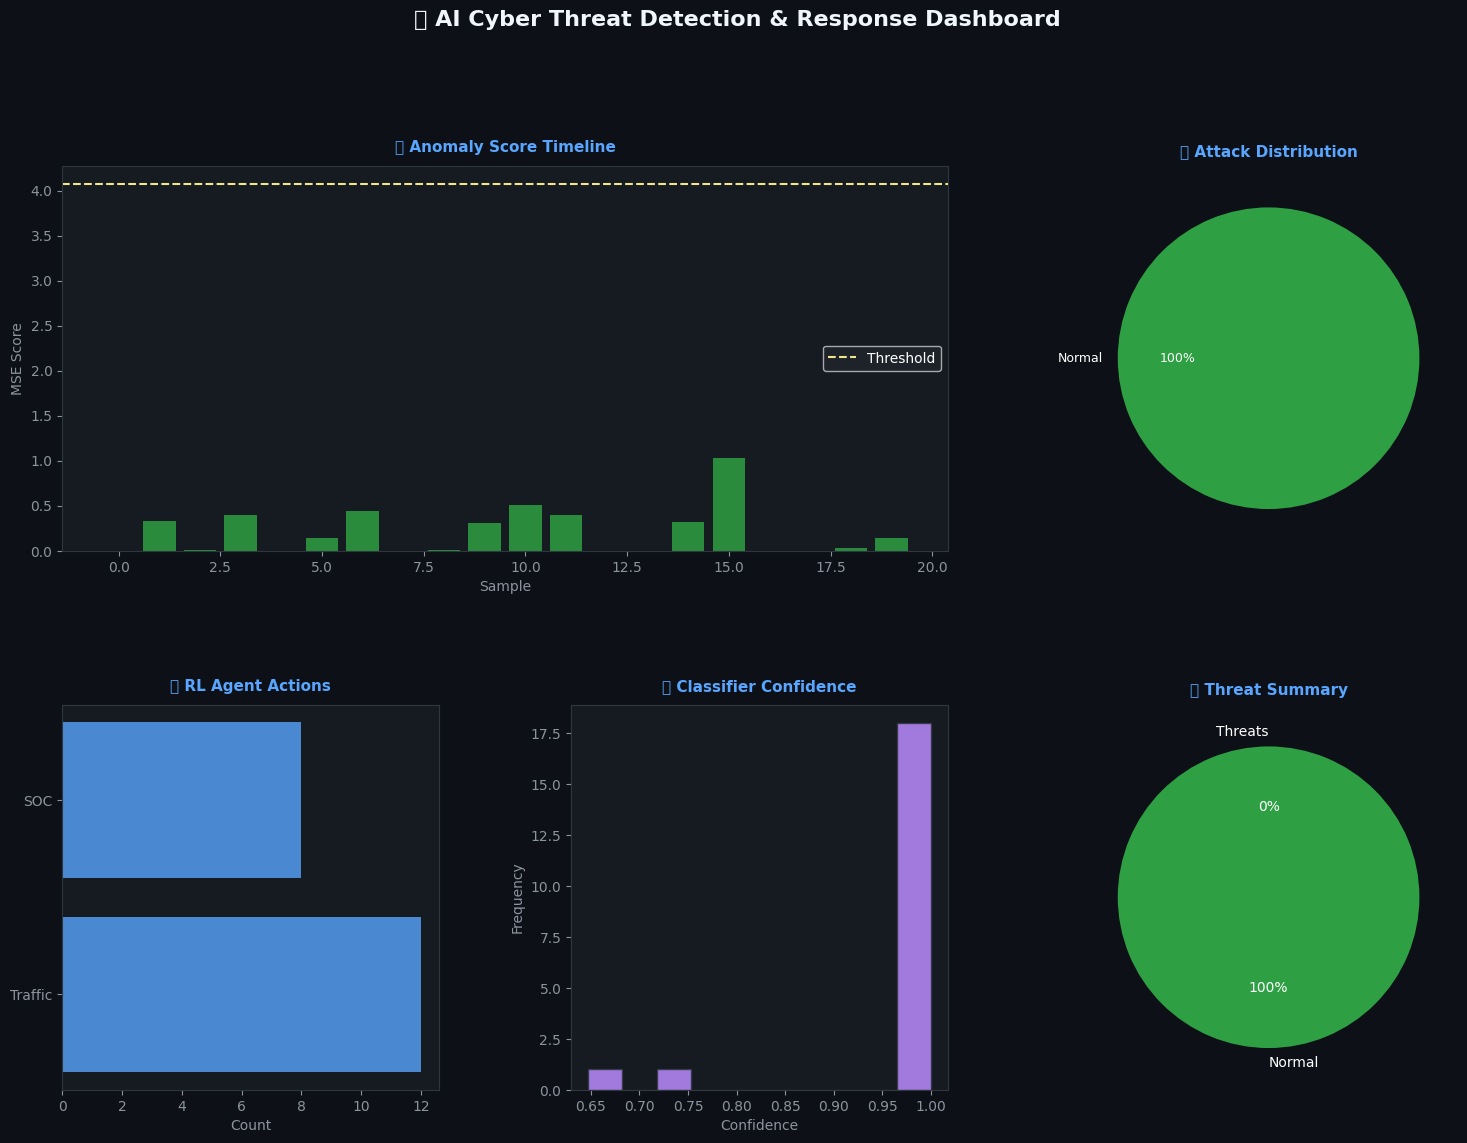

✅ Dashboard saved.


In [11]:
# Cell 9: Dashboard Plots (Colab-friendly)
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

def dark_ax(ax, title):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='#58a6ff', fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# 1. Anomaly Score Timeline
ax1 = fig.add_subplot(gs[0, :2])
dark_ax(ax1, '🔍 Anomaly Score Timeline')
colors = ['#ff4444' if a else '#2ea043' for a in results_df['is_anomaly']]
ax1.bar(results_df['sample'], results_df['anomaly_score'], color=colors, alpha=0.85)
ax1.axhline(float(np.load('data/threshold.npy')[0]), color='#f0e68c',
            linestyle='--', linewidth=1.5, label='Threshold')
ax1.set_xlabel('Sample', color='#8b949e')
ax1.set_ylabel('MSE Score', color='#8b949e')
ax1.legend(facecolor='#21262d', labelcolor='white')

# 2. Attack Type Distribution
ax2 = fig.add_subplot(gs[0, 2])
dark_ax(ax2, '🎯 Attack Distribution')
atk_counts = results_df['attack_type'].value_counts()
colors_pie = ['#2ea043','#ff4444','#f0883e','#58a6ff','#bc8cff']
ax2.pie(atk_counts.values, labels=atk_counts.index, autopct='%1.0f%%',
        colors=colors_pie[:len(atk_counts)], textprops={'color':'white', 'fontsize':9})

# 3. RL Response Actions
ax3 = fig.add_subplot(gs[1, 0])
dark_ax(ax3, '🤖 RL Agent Actions')
action_counts = results_df['rl_response'].value_counts()
short = [a.split()[-1] for a in action_counts.index]
bars = ax3.barh(short, action_counts.values, color='#58a6ff', alpha=0.8)
ax3.set_xlabel('Count', color='#8b949e')

# 4. Confidence Distribution
ax4 = fig.add_subplot(gs[1, 1])
dark_ax(ax4, '📊 Classifier Confidence')
ax4.hist(results_df['confidence'], bins=10, color='#bc8cff', alpha=0.85, edgecolor='#30363d')
ax4.set_xlabel('Confidence', color='#8b949e')
ax4.set_ylabel('Frequency', color='#8b949e')

# 5. Threat Status Summary
ax5 = fig.add_subplot(gs[1, 2])
dark_ax(ax5, '🛡️ Threat Summary')
n_threats = results_df['is_anomaly'].sum()
n_normal  = len(results_df) - n_threats
ax5.pie([n_threats, n_normal], labels=['Threats', 'Normal'],
        colors=['#ff4444', '#2ea043'], autopct='%1.0f%%',
        textprops={'color':'white', 'fontsize':10}, startangle=90)

fig.suptitle('🛡️ AI Cyber Threat Detection & Response Dashboard',
             color='#f0f6fc', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('data/dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117'); plt.show()
print("✅ Dashboard saved.")

In [15]:
# Cell 10: Write app.py and launch Streamlit
app_code = '''
import streamlit as st
import numpy as np
import pandas as pd
import tensorflow as tf
from stable_baselines3 import PPO
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

st.set_page_config(page_title="CyberShield AI", page_icon="ኇ37ቹ95;", layout="wide")

ACTIONS = {0:"✅ Allow",1:"☐ኂ21; Monitor",2:"ኂ74; Rate Limit",3:"ኆ83; Block IP",4:"ኆ80; Isolate/SOC Alert"}
CLASSES = ['DoS','Normal','Other','Probe','R2L','U2R']

@st.cache_resource
def load_models():
    ae  = tf.keras.models.load_model("model/autoencoder.h5", custom_objects={'mse': tf.keras.losses.MeanSquaredError()})
    clf = tf.keras.models.load_model("model/classifier.h5", compile=False)
    rl  = PPO.load("model/rl_ppo_agent")
    thr = float(np.load("data/threshold.npy")[0])
    return ae, clf, rl, thr

st.title("ኇ37ቹ95; CyberShield AI — Autonomous Threat Detection")
st.caption("Powered by Autoencoder + DNN + PPO Reinforcement Learning | NSL-KDD Dataset")

ae, clf, rl, threshold = load_models()
X_test = np.load("data/X_test.npy")

col1, col2 = st.columns([1, 2])
with col1:
    n = st.slider("Number of samples to analyze", 10, 200, 50)
    if st.button("ኆ40; Run Detection Pipeline"):
        indices = np.random.choice(len(X_test), n, replace=False)
        rows = []
        for idx in indices:
            x = X_test[idx].reshape(1,-1)
            error = float(np.mean((x - ae.predict(x,verbose=0))**2))
            is_anomaly = error > threshold
            probs = clf.predict(x,verbose=0)[0]
            atk_idx = np.argmax(probs)
            action,_ = rl.predict(X_test[idx].astype(np.float32), deterministic=True)
            rows.append({
                "Anomaly Score": round(error,5),
                "Threat": "ኃ08; ATTACK" if is_anomaly else "኉94; Normal",
                "Attack Type": CLASSES[atk_idx] if is_anomaly else "Normal",
                "Confidence": f"{probs[atk_idx]:.1%}",
                "RL Response": ACTIONS[int(action)]
            })
        df = pd.DataFrame(rows)
        with col2:
            st.dataframe(df, use_container_width=True, height=400)
        atk = df[df["Threat"]=="ኃ08; ATTACK"]
        m1,m2,m3 = st.columns(3)
        m1.metric("Total Samples", n)
        m2.metric("Threats Detected", len(atk), delta=f"{len(atk)/n:.0%}")
        m3.metric("Most Common Attack", atk["Attack Type"].mode()[0] if len(atk) else "None")
'''

with open('app.py', 'w') as f:
    f.write(app_code)
print("✅ app.py written.")

# Launch
!pip install pyngrok -q
from pyngrok import ngrok
import subprocess, time

# Using the provided token
NGROK_TOKEN = "3DWDE5WeHF2xtdSdUkHzfrg9AsH_5EQNQLDtJjd21t7pcabQ5"

ngrok.set_auth_token(NGROK_TOKEN)
# Terminate existing tunnels to avoid port conflicts
ngrok.kill()

proc = subprocess.Popen(['streamlit', 'run', 'app.py',
                         '--server.port=8501', '--server.headless=true'])
time.sleep(5)
tunnel = ngrok.connect(8501)
print(f"\nቷ60; Dashboard URL: {tunnel.public_url}")

✅ app.py written.

ቷ60; Dashboard URL: https://whomever-ritzy-stingily.ngrok-free.dev


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
# Cell 11: Mount Drive and backup project
from google.colab import drive
import shutil

drive.mount('/content/drive')

backup_path = '/content/drive/MyDrive/CyberShieldAI'
shutil.copytree('/content/model', f'{backup_path}/model', dirs_exist_ok=True)
shutil.copytree('/content/data',  f'{backup_path}/data',  dirs_exist_ok=True)
shutil.copy('/content/app.py',    f'{backup_path}/app.py')

print(f"✅ Project backed up to Google Drive at: {backup_path}")

Mounted at /content/drive
✅ Project backed up to Google Drive at: /content/drive/MyDrive/CyberShieldAI
